In [34]:
import cv2
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn.functional as F

In [35]:
from tqdm.auto import tqdm

In [36]:
import os

print(os.listdir("/kaggle/input/"))

['datasets']


In [37]:
import os

print(os.listdir("/kaggle/input/datasets"))

['subihanbiswas', 'ruizgara']


In [38]:
import os

path = "/kaggle/input/datasets/subihanbiswas/socofing204-split-closed-coorect/metadata_204_closedset_split_new_correct.csv"

print(os.path.exists(path))

True


In [39]:
df = pd.read_csv(
    "/kaggle/input/datasets/subihanbiswas/socofing204-split-closed-coorect/metadata_204_closedset_split_new_correct.csv"
    # /kaggle/input/datasets/subihanbiswas/socofing204-split-closed-coorect
)

train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df = df[df["split"]=="val"].reset_index(drop=True)
test_df = df[df["split"]=="test"].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

13699
2973
3051


In [40]:
train_transform = A.Compose([

    A.Resize(224, 224),

    A.Affine(
        rotate=(-10, 10),
        translate_percent=(-0.05, 0.05),
        scale=(0.95, 1.05),
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),

    A.GaussNoise(
        std_range=(0.01, 0.05),
        p=0.3
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()

])

In [41]:
val_transform = A.Compose([

    A.Resize(224, 224),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()

])

In [42]:
class FingerprintDataset(Dataset):

    def __init__(
            self,
            dataframe,
            transform=None
    ):

        self.df = dataframe
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]

        label = row["person_class"]

        # read grayscale image
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # convert to RGB
        image = np.stack(
            [image,image,image],
            axis=-1
        )

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        return image,label

In [43]:
train_dataset = FingerprintDataset(
    train_df,
    train_transform
)

val_dataset = FingerprintDataset(
    val_df,
    val_transform
)

test_dataset = FingerprintDataset(
    test_df,
    val_transform
)

In [44]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

13699
2973
3051


In [45]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(image.dtype)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
torch.float32
0


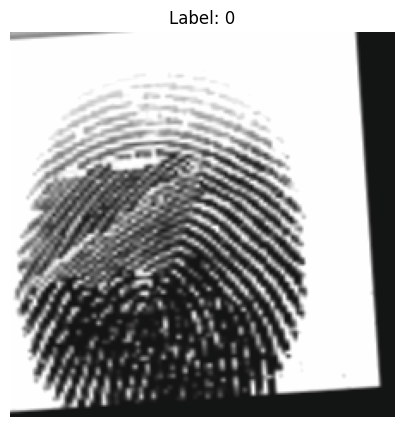

In [46]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

# C×H×W → H×W×C
image = image.permute(1,2,0).numpy()

# Denormalize
mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

image = image * std + mean

# Clip to [0,1]
image = np.clip(image,0,1)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

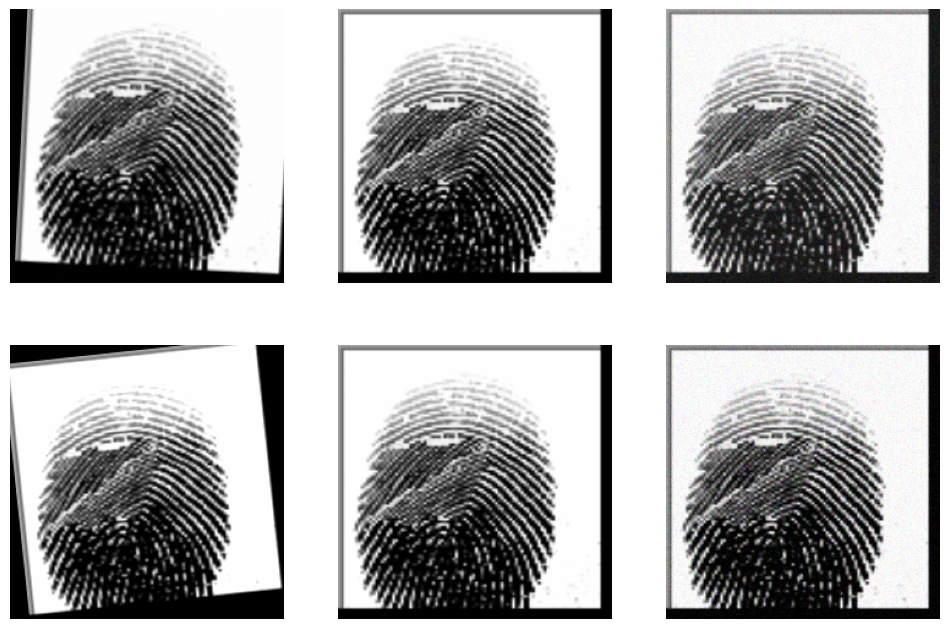

In [47]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax in axes.flatten():

    image, label = train_dataset[0]

    image = image.permute(1,2,0).numpy()

    image = image * std + mean
    image = np.clip(image,0,1)

    ax.imshow(image)
    ax.axis("off")

plt.show()

In [48]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True      # <-- add this
)

In [49]:
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [50]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [51]:
print(train_loader.batch_size)
print(len(train_loader.dataset))
print(len(train_loader))

64
13699
214


In [52]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


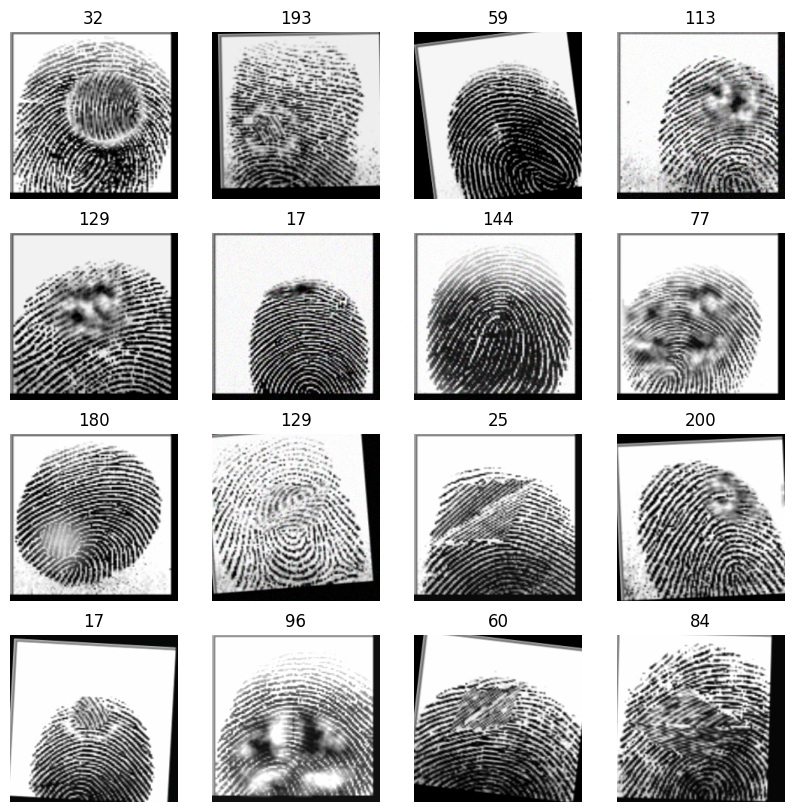

In [53]:
fig, axes = plt.subplots(4,4, figsize=(10,10))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    img = img * std + mean
    img = np.clip(img,0,1)

    ax.imshow(img)
    ax.set_title(labels[i].item())
    ax.axis("off")

plt.show()

In [54]:
import torch

dinov2 = torch.hub.load(
    'facebookresearch/dinov2',
    'dinov2_vitb14'
)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


In [55]:
for param in dinov2.parameters():
    param.requires_grad = False

In [56]:
import torch.nn as nn


class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x

In [57]:
class HybridFingerprintModel(nn.Module):

    def __init__(
        self,
        dinov2_model,
        num_classes=204,
        freeze_backbone=True
    ):

        super().__init__()

        self.dinov2 = dinov2_model

        # Freeze DINOv2 (Stage 1)
        if freeze_backbone:
            for p in self.dinov2.parameters():
                p.requires_grad = False

        self.cnn_branch = CNNBranch()

        self.embedding_head = nn.Sequential(

            nn.Linear(1280,1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3)

        )

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):

        # DINOv2 branch
        dino_features = self.dinov2(x)

        # CNN branch
        cnn_features = self.cnn_branch(x)

        # Concatenate
        features = torch.cat(
            [dino_features, cnn_features],
            dim=1
        )

        # 512-D embedding
        embedding = self.embedding_head(features)

        # Classification logits
        logits = self.classifier(embedding)

        normalized_embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )

        return logits ,normalized_embedding

        
    # def forward(self, x):

    #     with torch.no_grad():
    #         dino_features = self.dinov2(x)
    
    #     cnn_features = self.cnn_branch(x)
    
    #     print(
    #         "DINO:",
    #         dino_features.mean().item(),
    #         dino_features.std().item()
    #     )
    
    #     print(
    #         "CNN :",
    #         cnn_features.mean().item(),
    #         cnn_features.std().item()
    #     )
    
    #     features = torch.cat(
    #         [dino_features, cnn_features],
    #         dim=1
    #     )
    
    #     logits = self.classifier(features)
    
    #     return logits

In [58]:
# images, labels = next(iter(train_loader))

# images = images.cuda()

# outputs = model(images)

In [59]:
# model = HybridFingerprintModel(
#     dinov2_model=dinov2,
#     num_classes=204
# ).cuda()

In [60]:
# ── Dual-GPU setup ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPUs available: {torch.cuda.device_count()}")

model = HybridFingerprintModel(
    dinov2_model=dinov2,
    num_classes=204
)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel across {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)
# ──────────────────────────────────────────────────────────────────────

GPUs available: 2
Using DataParallel across 2 GPUs


In [61]:
# images, labels = next(iter(train_loader))

# images = images.cuda()

# model = model.cuda()

# outputs = model(images)

# print(outputs.shape)

In [62]:
trainable_params = 0
frozen_params = 0

for name, param in model.named_parameters():

    if param.requires_grad:
        trainable_params += param.numel()
    else:
        frozen_params += param.numel()

print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")
print(f"Total parameters: {trainable_params+frozen_params:,}")

Trainable parameters: 3,497,164
Frozen parameters: 86,580,480
Total parameters: 90,077,644


In [63]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

module.cnn_branch.features.0.weight
module.cnn_branch.features.0.bias
module.cnn_branch.features.1.weight
module.cnn_branch.features.1.bias
module.cnn_branch.features.4.weight
module.cnn_branch.features.4.bias
module.cnn_branch.features.5.weight
module.cnn_branch.features.5.bias
module.cnn_branch.features.8.weight
module.cnn_branch.features.8.bias
module.cnn_branch.features.9.weight
module.cnn_branch.features.9.bias
module.cnn_branch.features.12.weight
module.cnn_branch.features.12.bias
module.cnn_branch.features.13.weight
module.cnn_branch.features.13.bias
module.embedding_head.0.weight
module.embedding_head.0.bias
module.embedding_head.1.weight
module.embedding_head.1.bias
module.embedding_head.4.weight
module.embedding_head.4.bias
module.embedding_head.5.weight
module.embedding_head.5.bias
module.classifier.weight
module.classifier.bias


In [64]:
!pip install torchinfo

In [65]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 3, 224, 224),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
DataParallel                                       [32, 3, 224, 224]         [32, 204]                 --                        Partial
├─HybridFingerprintModel: 1-1                      [16, 3, 224, 224]         [16, 204]                 90,077,644                Partial
├─HybridFingerprintModel: 1-4                      --                        --                        (recursive)               Partial
│    └─DinoVisionTransformer: 2-1                  [16, 3, 224, 224]         [16, 768]                 86,580,480                False
│    └─DinoVisionTransformer: 2-7                  --                        --                        (recursive)               False
│    │    └─PatchEmbed: 3-1                        [16, 3, 224, 224]         [16, 256, 768]            (452,352)                 False
│    │    └─PatchEmbed: 3-6                  

In [66]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# model is already on device, don't reassign it here

outputs, embedding  = model(images)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Outputs shape:", outputs.shape)

Images shape : torch.Size([64, 3, 224, 224])
Labels shape : torch.Size([64])
Outputs shape: torch.Size([64, 204])


In [67]:
probs = torch.softmax(outputs, dim=1)

print(probs.shape)
print(probs[0].sum())

torch.Size([64, 204])
tensor(1., device='cuda:0', grad_fn=<SumBackward0>)


In [68]:
print(torch.cuda.memory_allocated()/1024**3, "GB")

2.695655345916748 GB


In [69]:
criterion = nn.CrossEntropyLoss()

In [70]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-3,
    weight_decay=1e-4
)

In [71]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [72]:
scaler = torch.amp.GradScaler('cuda')

In [73]:
# def train_one_epoch(
#         model,
#         loader,
#         criterion,
#         optimizer,
#         scaler,
#         device
# ):

#     model.train()

#     running_loss = 0
#     correct = 0
#     total = 0

#     for images, labels in loader:

#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         with torch.amp.autocast('cuda'):

#             outputs = model(images)

#             loss = criterion(outputs, labels)

#         scaler.scale(loss).backward()

#         scaler.step(optimizer)

#         scaler.update()

#         running_loss += loss.item() * labels.size(0)

#         preds = outputs.argmax(1)

#         correct += (preds == labels).sum().item()

#         total += labels.size(0)

#     epoch_loss = running_loss / total
#     epoch_acc = correct / total

#     return epoch_loss, epoch_acc

In [74]:

def train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        scaler,
        device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix(
            loss=running_loss/total,
            acc=correct/total
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [75]:
@torch.no_grad()
def validate(
        model,
        loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [76]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.amp.autocast('cuda'):
    outputs, embedding  = model(images)
    loss = criterion(outputs, labels)

print(outputs.requires_grad)
print(loss.requires_grad)

True
True


In [77]:
import matplotlib.pyplot as plt

def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")

    plt.legend()

    plt.grid(True)

    # Accuracy
    plt.subplot(1,2,2)

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [78]:
from tqdm.auto import tqdm
import torch


def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        scaler,
        device,
        initial_epochs=50,
        patience=10
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    early_stop_counter = 0
    current_epoch = 0
    epochs_to_run = initial_epochs

    while True:

        for _ in range(epochs_to_run):

            current_epoch += 1

            # ==========================
            # Training
            # ==========================
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device
            )

            # ==========================
            # Validation
            # ==========================
            val_loss, val_acc = validate(
                model,
                val_loader,
                criterion,
                device
            )

            # ==========================
            # Scheduler
            # ==========================
            scheduler.step(val_acc)

            # ==========================
            # Save history
            # ==========================
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # ==========================
            # Print epoch results
            # ==========================
            print(
                f"Epoch [{current_epoch}] "
                f"| Train Loss: {train_loss:.4f}"
                f" | Train Acc: {train_acc:.4f}"
                f" | Val Loss: {val_loss:.4f}"
                f" | Val Acc: {val_acc:.4f}"
            )

            # ==========================
            # Save best model
            # ==========================
            if val_acc > best_val_acc:

                best_val_acc = val_acc
                early_stop_counter = 0

                # torch.save(
                #     model.state_dict(),
                #     "best_model.pth"
                # )
                torch.save(
                    (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
                    "best_model.pth"
                )

                print(
                    f"Best model saved! "
                    f"(Val Acc = {best_val_acc:.4f})"
                )

            else:

                early_stop_counter += 1

            # ==========================
            # Save last model
            # ==========================
            
            # torch.save(
            #     model.state_dict(),
            #     "last_model.pth"
            # )
            torch.save(
                (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
                "last_model.pth"
            )

            # ==========================
            # Early stopping
            # ==========================
            if early_stop_counter >= patience:

                print("\nEarly stopping triggered!")

                return history, best_val_acc

        # =====================================
        # Ask whether to continue training
        # =====================================
        answer = input(
            "\nContinue training? (y/n): "
        ).lower()

        if answer != "y":

            print("\nTraining finished.")

            break

        epochs_to_run = int(
            input(
                "How many more epochs? "
            )
        )

    # return history, best_val_acc
    plot_history(history)

    return history, best_val_acc

  0%|          | 0/214 [00:00<?, ?it/s]

Epoch [1] | Train Loss: 4.0597 | Train Acc: 0.1415 | Val Loss: 2.6943 | Val Acc: 0.3296
Best model saved! (Val Acc = 0.3296)


  0%|          | 0/214 [00:00<?, ?it/s]

Epoch [2] | Train Loss: 2.5080 | Train Acc: 0.3632 | Val Loss: 1.9048 | Val Acc: 0.4904
Best model saved! (Val Acc = 0.4904)


  0%|          | 0/214 [00:00<?, ?it/s]

...

Epoch [44] | Train Loss: 0.0716 | Train Acc: 0.9782 | Val Loss: 0.0209 | Val Acc: 0.9936


  0%|          | 0/214 [00:00<?, ?it/s]

Epoch [45] | Train Loss: 0.0633 | Train Acc: 0.9803 | Val Loss: 0.0211 | Val Acc: 0.9936



Continue training? (y/n):  n



Training finished.


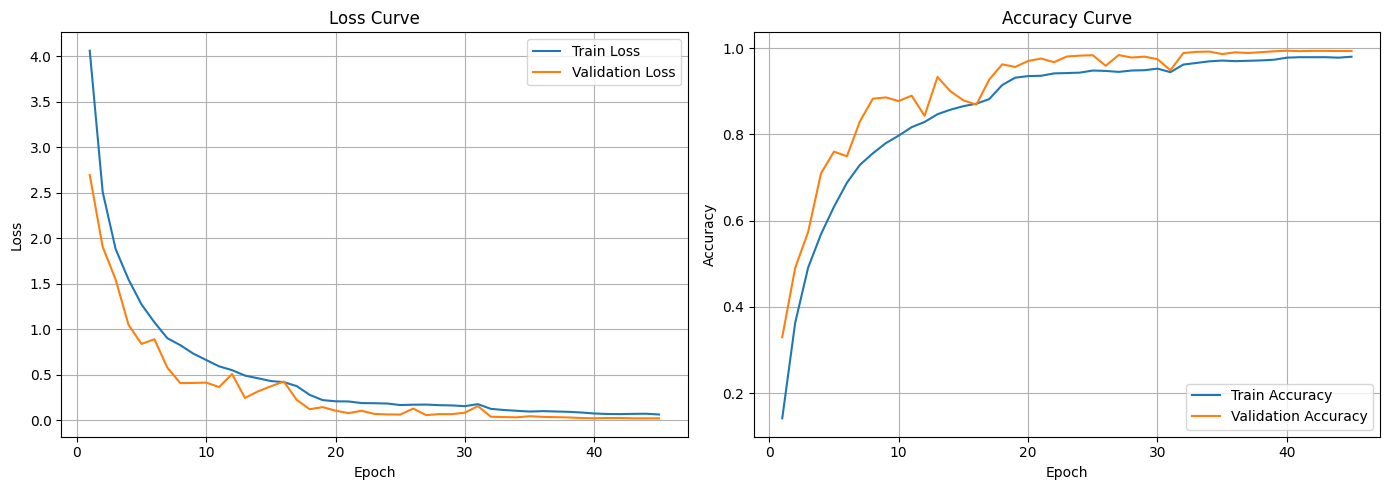

In [79]:
history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    initial_epochs=40,
    patience=10
)

In [80]:
import torch
import numpy as np
from tqdm.auto import tqdm


@torch.no_grad()
def test_model(
        model,
        test_loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    pbar = tqdm(test_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)

        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

    test_loss = running_loss / total

    return (
        test_loss,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [81]:
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_metrics(
        test_loss,
        all_labels,
        all_preds,
        all_probs
):

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    top3_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=3
    )

    top5_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=5
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    report = classification_report(
        all_labels,
        all_preds
    )

    print("="*50)
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Top-1 Accuracy : {accuracy:.4f}")
    print(f"Top-3 Accuracy : {top3_acc:.4f}")
    print(f"Top-5 Accuracy : {top5_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print("="*50)

    print("\nClassification Report:\n")

    print(report)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap='Blues'
    )

    plt.title("Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

    results = {

        "test_loss": test_loss,

        "accuracy": accuracy,

        "top3_accuracy": top3_acc,

        "top5_accuracy": top5_acc,

        "precision": precision,

        "recall": recall,

        "f1_score": f1,

        "confusion_matrix": cm,

        "classification_report": report

    }

    return results

  0%|          | 0/48 [00:00<?, ?it/s]

Test Loss      : 0.0276
Top-1 Accuracy : 0.9925
Top-3 Accuracy : 0.9997
Top-5 Accuracy : 0.9997
Precision      : 0.9930
Recall         : 0.9925
F1 Score       : 0.9925

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        15
           8       1.00      1.00      1.00        15
           9       0.94      1.00      0.97        15
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        15
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00       

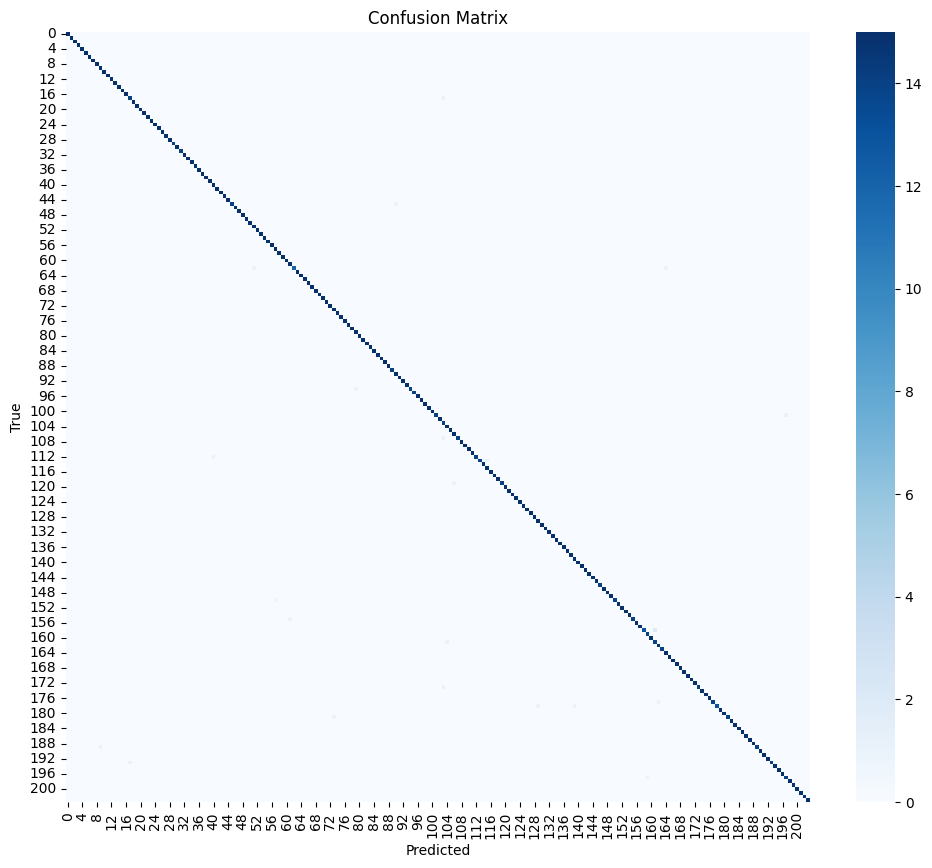

In [82]:
test_loss, labels, preds, probs = test_model(
    model,
    test_loader,
    criterion,
    device=device
)

results = evaluate_metrics(
    test_loss,
    labels,
    preds,
    probs
)